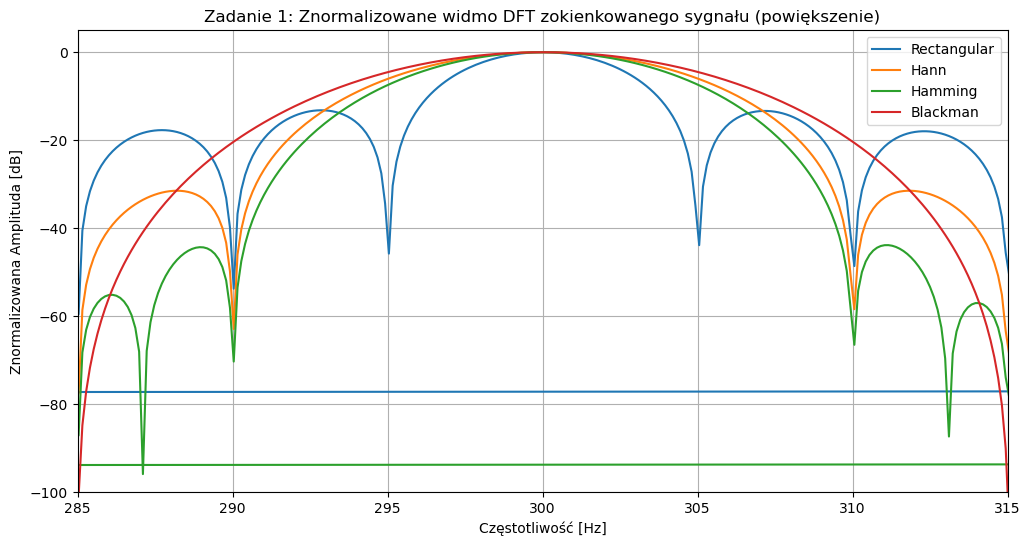

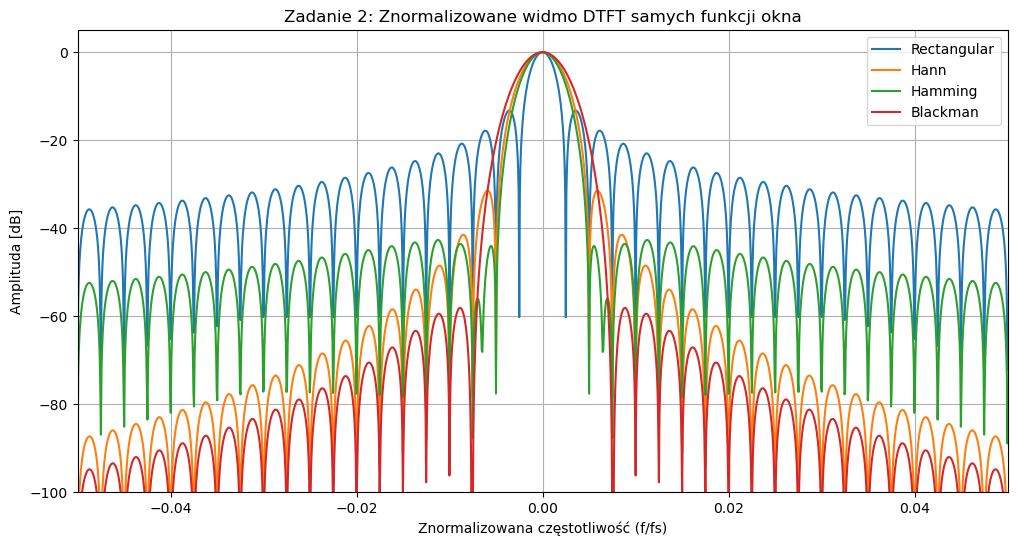

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal.windows import hann, hamming, blackman

f1 = 300.0
f2 = 300.25
f3 = 299.75

A1 = 2.0
A2 = 0.1 * A1   # 0.20
A3 = 0.01 * A1  # 0.02

N = 400
fs = 2000

k = np.arange(N)
# Składowe sygnału
x1 = A1 * np.sin(2 * np.pi * f1 / fs * k)
x2 = A2 * np.sin(2 * np.pi * f2 / fs * k)
x3 = A3 * np.sin(2 * np.pi * f3 / fs * k)
x = x1 + x2 + x3

windows = {
    'Rectangular': np.ones(N),
    'Hann': hann(N, sym=False),
    'Hamming': hamming(N, sym=False),
    'Blackman': blackman(N, sym=False)
}

N_fft = 16384 
freqs = fftfreq(N_fft, 1/fs)

plt.figure(figsize=(12, 6))

for name, win in windows.items():
    x_windowed = x * win
    
    X = fft(x_windowed, N_fft)
    
    mag = np.abs(X)
    mag_norm = mag / np.max(mag)
    mag_db = 20 * np.log10(mag_norm + 1e-12) # 1e-12 zapobiega błędowi logarytmu z zera
    
    plt.plot(freqs, mag_db, label=name)

plt.xlim(285, 315)
plt.ylim(-100, 5)
plt.title("Zadanie 1: Znormalizowane widmo DFT zokienkowanego sygnału (powiększenie)")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Znormalizowana Amplituda [dB]")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

freqs_shifted = fftshift(fftfreq(N_fft, 1))

for name, win in windows.items():
    # FFT samego okna
    W = fft(win, N_fft)
    W_shifted = fftshift(W)
    
    mag_W = np.abs(W_shifted)
    mag_W_norm = mag_W / np.max(mag_W)
    mag_W_db = 20 * np.log10(mag_W_norm + 1e-12)
    
    plt.plot(freqs_shifted, mag_W_db, label=name)

# Zbliżenie na listek główny i pierwsze listki boczne
plt.xlim(-0.05, 0.05)
plt.ylim(-100, 5)
plt.title("Zadanie 2: Znormalizowane widmo DTFT samych funkcji okna")
plt.xlabel("Znormalizowana częstotliwość (f/fs)")
plt.ylabel("Amplituda [dB]")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
s